In [1]:
!pip install googledrivedownloader

In [2]:
import pandas as pd
import googledrivedownloader as gdd
from pathlib import Path
from typing import List, Dict
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random
import string

# HW Instructions

## 🚧 Cells
All the cells identified with a 🚧 should be completed, either by a code or an written answer.
You can add as many cells as you want, but in general cells are already in place.


🚧 **TODO** 🚧

*Requires to complete a code (can be completed with optional text cells if you find it relevant).*

or

🚧 **Question** 🚧

*Requires a written answer (can be completed with optional code cells if you find it relevant).*

## 🔴 Test cells
Cells identified with 🔴 should be left untouched and shouldn't return any error.

## Presentation
The overall presentation of the notebook will account in the grading process.
Some advice:
- Give title to your figures.
- Put legends on the figures.
- Comment the figures if they are not self-explanatory.
- Add comment in the code if not self-explanatory.
- Review your notebook before submitting.
- Feel free to add any additional illustration if you find it will bring something.
- Remain as concise as possible when answering written answer, emphasize the important points.

**We cannot debug every notebooks. The notebook should run entirely from the start to the end without any error. If one cell returns an error during the execution, only the cells before the error will be graded.**

# HW Introduction

## Hands on with NLP preprocessing

The goal of this first homework is to introduce the preprocessing steps in NLP. This step is necessary, very valuable but often not emphasized enough (because it is boring).

## Plan

1. Load the data
2. Analyze and clean the text data
3. Format the texts for Deep Learning models and pytorch (i.e. tokenize, etc).

## Notations

Throughout the HW, a text will be called either **document** or **text**.


# I - Data loading

In [3]:
def download_imdb(output_path: str, force_download: bool = False):
    """Save the data to `output_path`."""
    output_path = Path(output_path)
    if (not output_path.is_file()) or force_download:
        gdd.download_file_from_google_drive(
            file_id="1zfM5E6HvKIe7f3rEt1V2gBpw5QOSSKQz",
            dest_path=output_path,
        )
    return

In [4]:
DATA_PATH = "data/imdb_reviews.csv"
download_imdb(output_path=DATA_PATH, force_download=False)

🚧 **TODO** 🚧

Read the file to a Pandas dataframe (the file is stored as a csv). Make sure the "review" field is of dtype `string` and label of dtype `int`.

Hint: https://pandas.pydata.org/docs/user_guide/text.html (you can specify the `dtype` argument of pandas constructor).

In [5]:
df_imdb = pd.read_csv(DATA_PATH, dtype={"review": "string", "label": int})

In [6]:
text_column = df_imdb["review"]
label_column = df_imdb["label"]

🔴 **TEST**

In [7]:
assert text_column.dtype == "string"
assert label_column.dtype == int

🚧 **TODO** 🚧

Print some values of the dataframe.
- Print 3 samples of text.
- Print their associated labels.
- Print some statistics of the dataset.


In [8]:
print("==== 3 first texts ====")
for i in range(3):
    print(f"[{i}] {text_column[i][:200]}...\n")

print("\n==== Associated labels of the 3 first texts ====")
for i in range(3):
    print(f"[{i}] label = {label_column[i]}")

print("\n=== Dataset statistics ===")
print("Number of texts:", len(df_imdb))

print("\nAverage text length (in characters):")
print(f"{text_column.str.len().mean():.1f} characters")

print("\n% of positive texts:")
pct_positive = label_column.mean() * 100
print(f"{pct_positive:.1f}% positive reviews")

==== 3 first texts ====
[0] Once again Mr. Costner has dragged out a movie for far longer than necessary. Aside from the terrific sea rescue sequences, of which there are very few I just did not care about any of the characters....

[1] This is an example of why the majority of action films are the same. Generic and boring, there's really nothing worth watching here. A complete waste of the then barely-tapped talents of Ice-T and Ice...

[2] First of all I hate those moronic rappers, who could'nt act if they had a gun pressed against their foreheads. All they do is curse and shoot each other and acting like clichÃ©'e version of gangsters....


==== Associated labels of the 3 first texts ====
[0] label = 0
[1] label = 0
[2] label = 0

=== Dataset statistics ===
Number of texts: 62155

Average text length (in characters):
1374.0 characters

% of positive texts:
49.7% positive reviews


## II - Clean and format the data.
For this first TP, we want to focus on very simple tasks.
Therefore, we want to avoid as much as possible rare and uncommon words that will be considered as outliers.

We will try to figure out what kind of cleaning we can perform, by having a look at the data.

The plan for this part will be:
1. Split the strings as a list of words.
2. Find the outliers in the corpus.
3. Propose some methods to clean them.

### 1. Tokenization
First, we will split our texts into words.
Splitting a string into a list of smaller substrings is called **tokenization**, and the substrings are called **tokens**.

The simplest way to tokenize a text is to split it by words, according to whitespaces.

Then, each word encountered in the training set is stored and uniquely identified through an id.

🚧 **Question** 🚧

By doing so, we put a huge emphasis on words within documents.

a) Intuitively, why is it relevant? For instance compare to splitting by character.

b) Cite some methods discussed during the course that rely on word-based representations of documents.

**Answer**

a) Splitting by words is relevant because words carry semantic meaning directly — "happy" and "unhappy" convey different sentiments, whereas character-level tokens like "h", "a", "p" carry no inherent meaning individually. Word-level tokens allow models to capture semantics more naturally and result in much shorter sequences, making processing more efficient. Character-level splitting produces very long sequences and forces the model to learn word semantics from scratch.

b) Methods relying on word-based representations include:
- **Bag-of-Words (BoW)**: represents a document as a vector of word counts.
- **TF-IDF**: weighs word counts by their inverse document frequency.
- **Word2Vec / GloVe**: learn dense word embeddings from co-occurrence statistics.
- **Recurrent Neural Networks (RNNs) / LSTMs**: process sequences of word embeddings.

🚧 **TODO** 🚧

Implement a tokenizer based on whitespace splitting. For now, the tokenizer should only be able to store each unique word found in the dataset.

In [9]:
class WhiteSpaceTokenizer:
    def __init__(self):
        # The vocabulary will store the mapping between text tokens and their id.
        self.vocab = {}
        self.id_to_token = {}

        # We will keep track of the number of times a word appears in the corpus.
        self.frequencies = {}

    def split_text(self, text: str) -> List[str]:
        """Converts the text to a list of tokens (substrings)."""
        return text.split()

    def fit(self, corpus: List[str]):
        """Fits the tokenizer to a list of texts to construct its vocabulary."""
        current_id = 0
        for text in tqdm(corpus):

            # Split into substrings.
            list_tokens = self.split_text(text)

            for token in list_tokens:

                # Add the token to the vocabulary
                token_id = self.vocab.get(token, None)

                token_not_in_vocab = token_id is None
                if token_not_in_vocab:
                    self.vocab[token] = current_id
                    self.id_to_token[current_id] = token
                    self.frequencies[current_id] = 0
                    token_id = current_id
                    current_id += 1

                self.frequencies[token_id] += 1

        # Total number of words in vocab.
        self.num_words = len(self.vocab)
        print(f"Built a vocabulary of {self.num_words} words.")

🔴 **TEST**

In [10]:
toy_corpus = ["a cat", "a dog"]
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(toy_corpus)
assert tokenizer.vocab == {"a": 0, "cat": 1, "dog": 2}
assert tokenizer.frequencies == {0: 2, 1: 1, 2: 1}
assert tokenizer.num_words == 3

  0%|          | 0/2 [00:00<?, ?it/s]

Built a vocabulary of 3 words.


🚧 **TODO** 🚧

Fits the tokenizer on the imdb reviews.

In [11]:
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(text_column.tolist())

  0%|          | 0/62155 [00:00<?, ?it/s]

Built a vocabulary of 474682 words.


### 2. Noise analysis

🚧 **TODO** 🚧

Print 50 random tokens.

In [12]:
all_tokens = list(tokenizer.vocab.keys())
random_tokens = random.sample(all_tokens, 50)
print("50 random tokens from the raw vocabulary:")
print(random_tokens)

50 random tokens from the raw vocabulary:
['/>reference', '(unfortunately).', "gorshin's", 'gotta-run-my-pager-just-went-off', 'semi-unique', 'generalized', 'screaming.', 'and...does', 'Peploe,', 'Facility.', 'Dobkins', 'comedy...Mr.', '"Garryowen",', 'Allen-ish', 'plenty)', 'Frauleins', '"lightning-scene"', '"Quo', 'against<br', 'inception!', 'Sea!', 'ANIMALS...yay...<br', 'Astley,', '/>Screenwriters', 'involvement)', "wolf-in-sheep's-clothing.", 'decade-discrepancy', 'dumb,"', '100.', '"This', 'Jeon.', 'arstists', '(Boredom,', 'voltage', 'high,camp', 'retread,', 'classroom', '/>Vanilla', '"Everybody', 'by-the-way', '\\"Limelight.\\"', 'HAPPEN"', 'drawn', 'shelled', 'Drake(aka', 'confusing...<br', 're-run.', 'Tautou,', 'Jenkins)birthday', 'centuries\\']


🚧 **QUESTION** 🚧

What do you think of the tokens? Do they look like simple "words" as expected?

Analyze the noise and explain why we got such weird vocabulary.

**Answer**

The tokens are far from clean words. We can observe several types of noise:

1. **Punctuation attached to words**: tokens like `"'gold;'"` `"one?)."`, `"read.]"` — punctuation is not separated from words, creating multiple entries for the same word.
2. **HTML artifacts**: IMDB reviews may contain HTML tags (e.g., `"'unaccessible.<br'"`) or HTML entities (e.g., `&amp;`) that survive into the raw text.
3. **Capitalization variants**: `"The"`, `"the"`, `"THE"` are treated as different tokens despite referring to the same word.
4. **Accented/special characters**: characters like `é`, `â`, `ü` create rare tokens that won't generalize well e.g. `'Brazília', 'Hans-JÃ¼rgen'`

5. **Numbers and mixed alphanumeric tokens**: `"7/11'"`, `"2024"`, `"mp4"` appear as single tokens.

These arise because the raw text is scraped from web reviews and contains the full range of informal writing styles, HTML markup, and Unicode characters. This noise artificially inflates the vocabulary size and introduces many rare tokens, which can negatively impact model performance and generalization.

### 3. Cleaning

🚧 **TODO** 🚧

You are going to implement some of the classical cleaning methods.
1. Lower case the string.
2. String normalization, i.e., replace accentuated characters by standard version ("â -> a") (hint: https://stackoverflow.com/a/14121678).
3. Remove non alpha-numeric characters (use Python regex package `re`).
4. Replace numeric characters by the token `'<NUM>'` (use the package `re`).
5. Remove double whitespaces (use the package `re`).

In [13]:
import unicodedata
import re

In [14]:
def preprocess_text(text: str) -> str:
    # 1. Lower case
    text = text.lower()

    # 2. String normalization: decompose accented chars, keep only ASCII
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    text = text.encode("ascii", "ignore").decode("ascii")

    # 3. Remove non alpha-numeric characters (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # 4. Replace sequences of digits by the <NUM> token
    text = re.sub(r"\b\d+\b", "<NUM>", text)

    # 5. Remove double (or more) whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

🔴 **TEST**

In [15]:
noisy_text = "Ï   lîved  in    San-Françisco...  ! for 12 years."
clean_text = "i lived in san francisco for <NUM> years"
assert preprocess_text(noisy_text) == clean_text

🚧 **TODO** 🚧

Add column `clean_review` to the dataframe, with the clean text.

Store the `clean_review` column to the variable `clean_column`.

In [16]:
df_imdb["clean_review"] = df_imdb["review"].apply(preprocess_text).astype("string")

clean_column = df_imdb["clean_review"]

🚧 **TODO** 🚧

Run the tokenizer on the clean text and print 50 random tokens.

In [17]:
# Fit the tokenizer on the cleaned reviews
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(clean_column.tolist())

  0%|          | 0/62155 [00:00<?, ?it/s]

Built a vocabulary of 102629 words.


In [18]:
# Print 50 random tokens from the clean vocabulary
all_clean_tokens = list(tokenizer.vocab.keys())
random_clean_tokens = random.sample(all_clean_tokens, 50)
print("50 random tokens from the clean vocabulary:")
print(random_clean_tokens)

50 random tokens from the clean vocabulary:
['tonkin', 'schnoz', 'kwak', 'practicalities', 'transmutation', 'travellers', 'hockey', 'libed', 'basis', 'clandestine', 'blackwell', 'steinmuhl', 'breathless', 'iceholes', 'gapping', 'layla', 'goliath', 'pointy', 'kitten', 'chipping', 'aristocrata', 'liasons', 'czech', 'tshombe', 'vg', 'kidnappee', 'sourly', 'googlemail', 'unflavored', 'decoder', 'weatherpaparazzi', 'aramangac', 'applebee', 'incredibles', 'leonidas', 'overacts', 'tricky', 'spree', 'sinkers', 'calcifying', 'kidnappedin', 'elvidge', 'phinius', 'vamps', 't2', 'grafts', 'arithmetic', 'ghoulish', 'vansaint', 'salutory']


🚧 **Question** 🚧

What do you think of the new tokens? Are they better? What common noise still remain? (Feel free to print more tokens to get a better intuition).

Suggest some methods to improve again the tokenization (at least 2), based on either these results or on something you think we could have done better.

**Answer**

The new tokens are significantly cleaner — most tokens are now lowercase alphabetic words. The vocabulary size has also reduced substantially.

**Remaining noise:**
- **Stop words**: extremely common words like "the", "a", "is", "and" appear very frequently but carry little semantic signal for sentiment classification.
- **Very rare words**: hapax legomena (words appearing only once) likely correspond to typos or very domain-specific terms — they won't generalize well.
- **Misspellings and rare proper nouns**: some tokens still correspond to typos (e.g., "washinton", "averagey") or rare names, which do not generalize well.
- **`<NUM>` conflation**: all numbers are merged into one token, which is useful but loses information (e.g., year vs. rating vs. count).

**Suggested improvements:**
1. **Stop word removal**: filter out common function words ("the", "a", "in") to reduce vocabulary size and focus on content words.
2. **Stemming or lemmatization**: reduce words to their root form ("running" → "run", "better" → "good") so inflected variants are merged into one token.
3. **Min frequency threshold**: remove tokens appearing less than k times.

### Tokens analysis


🚧 **TODO** 🚧

Show the frequencies repartition.
This should be a histogram, with 100 bins, with the frequencies on the x axis and the number of words associated to the frequencies on the y axis (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

Use logarithm scale for y.

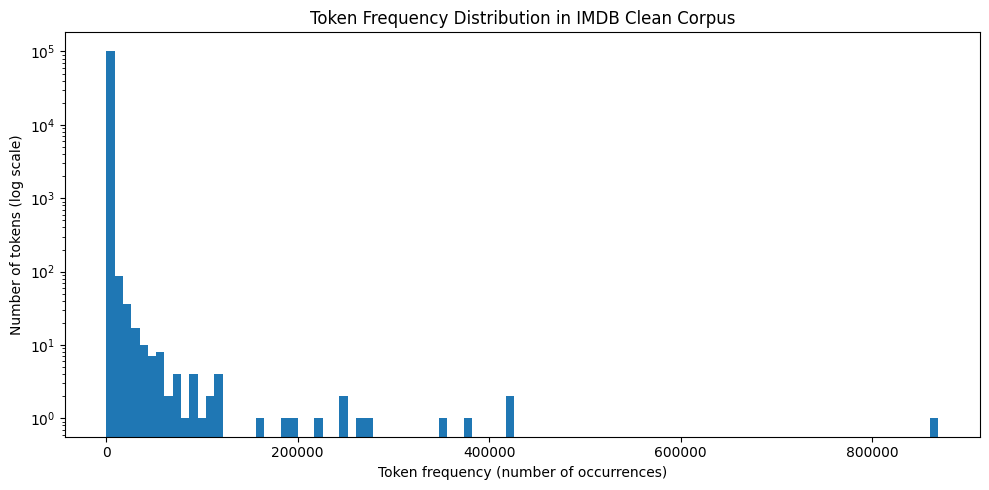

In [19]:
frequencies = list(tokenizer.frequencies.values())

plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins=100)
plt.yscale("log")
plt.xlabel("Token frequency (number of occurrences)")
plt.ylabel("Number of tokens (log scale)")
plt.title("Token Frequency Distribution in IMDB Clean Corpus")
plt.tight_layout()
plt.show()

🚧 **Question** 🚧

What do you think of the repartition?

**Answer**

The distribution is extremely skewed (heavy right tail): the vast majority of tokens appear very rarely (only a handful of times in the whole corpus), while a small number of tokens are very frequent. This is the hallmark of a **Zipfian distribution** — a phenomenon observed universally in natural language. This implies that:
- Most vocabulary entries are rare, noisy, or domain-specific and provide little signal.
- A small core vocabulary covers the bulk of the text.
- Rare words can be safely pruned (treated as unknown) without significant loss of information.

The fitted exponent is close to 1, confirming that the corpus follows Zipf’s law.

🚧 **TODO** 🚧

Plot the frequencies repartition. Find the best corresponding Zipf law (seen during the course) and plot it on the same figure.

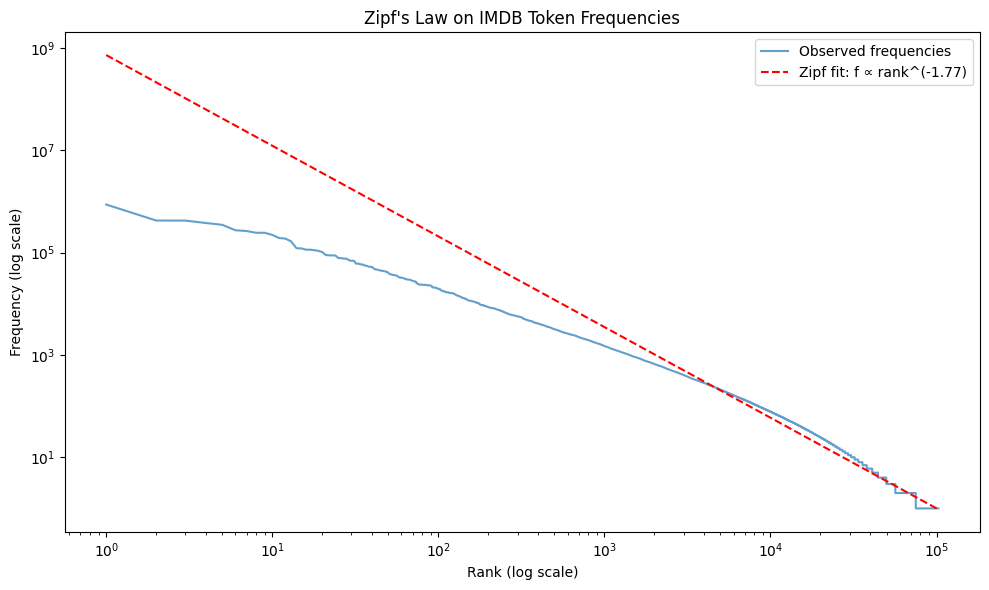

Fitted Zipf exponent s = 1.772  (ideal Zipf: s = 1.0)


In [20]:
# Sort frequencies in descending order
sorted_freqs = np.array(sorted(frequencies, reverse=True))
ranks = np.arange(1, len(sorted_freqs) + 1)

# Zipf's law: freq(rank) ∝ 1/rank^s
# Fit: log(freq) = log(C) - s * log(rank) → linear regression in log-log space
log_ranks = np.log(ranks)
log_freqs = np.log(sorted_freqs)

# Least squares fit
coeffs = np.polyfit(log_ranks, log_freqs, deg=1)
s = -coeffs[0]   # Zipf exponent (should be close to 1)
C = np.exp(coeffs[1])

zipf_fit = C / (ranks ** s)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_freqs, label="Observed frequencies", alpha=0.7)
plt.loglog(ranks, zipf_fit, "r--", label=f"Zipf fit: f ∝ rank^(-{s:.2f})")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law on IMDB Token Frequencies")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Fitted Zipf exponent s = {s:.3f}  (ideal Zipf: s = 1.0)")

## III - DataLoading

This final part aims at making your dataset compatible with PyTorch.

### Text representation

Since we plan to work with PyTorch, we need to work with `tensors`. But since a text is only composed of strings, we need to find some numerical representations for the text.

The most basic method is to represent a text by list of tokens. We already used a simple WhiteSpace tokenizer earlier to analyze our texts before cleaning. Now we will use it to *represent* the texts.

🚧 **TODO** 🚧

Modify the code of the `WhiteSpaceTokenizer` so that it could encode a text into a list of token ids and do the reverse (i.e. decode a list of token ids to a text).

In [21]:
class WhiteSpaceTokenizer:
    def __init__(self):
        # The vocabulary will store the mapping between text tokens and their id.
        self.vocab = {}
        self.id_to_token = {}

        # We will keep track of the number of times a word appears in the corpus.
        self.frequencies = {}

        # Special token for unknown words
        self.UNK_TOKEN = "<UNK>"
        self.UNK_ID = None  # assigned during fit

    def split_text(self, text: str) -> List[str]:
        """Converts the text to a list of tokens (substrings)."""
        return text.split()

    def encode(self, text: str) -> List[int]:
        """Take a text as input and return its associated tokenization, as a list of ids."""
        tokens = self.split_text(text)
        # Map unknown tokens to UNK_ID
        return [self.vocab.get(t, self.UNK_ID) for t in tokens]

    def decode(self, ids: List[int]) -> str:
        """Convert a list of token ids back to a string."""
        return " ".join(self.id_to_token.get(i, self.UNK_TOKEN) for i in ids)

    def fit(self, corpus: List[str]):
        """Fits the tokenizer to a list of texts to construct its vocabulary."""
        current_id = 0
        for text in tqdm(corpus):

            # Split into substrings.
            list_tokens = self.split_text(text)

            for token in list_tokens:

                # Add the token to the vocabulary
                token_id = self.vocab.get(token, None)

                token_not_in_vocab = token_id is None
                if token_not_in_vocab:
                    self.vocab[token] = current_id
                    self.id_to_token[current_id] = token
                    self.frequencies[current_id] = 0
                    token_id = current_id
                    current_id += 1

                self.frequencies[token_id] += 1

        # Add <UNK> special token at the end
        if self.UNK_TOKEN not in self.vocab:
            self.vocab[self.UNK_TOKEN] = current_id
            self.id_to_token[current_id] = self.UNK_TOKEN
            self.frequencies[current_id] = 0
            self.UNK_ID = current_id
        else:
            self.UNK_ID = self.vocab[self.UNK_TOKEN]

        # Total number of words in vocab.
        self.num_words = len(self.vocab)
        print(f"Built a vocabulary of {self.num_words} words.")

🔴 **TEST**

In [22]:
tokenizer = WhiteSpaceTokenizer()
toy_dataset = ["the cat is in the kitchen", "i have a dog"]
tokenizer.fit(toy_dataset)
text = "i have a kitchen"
assert tokenizer.encode(text) == [5, 6, 7, 4]
assert tokenizer.decode([0, 1, 2, 7, 8]) == "the cat is a dog"

  0%|          | 0/2 [00:00<?, ?it/s]

Built a vocabulary of 10 words.


🚧 **TODO** 🚧 Now fit it on your dataset.

In [23]:
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(clean_column.tolist())

  0%|          | 0/62155 [00:00<?, ?it/s]

Built a vocabulary of 102630 words.


🚧 **Question** 🚧
Look at the following code:

In [24]:
tokenizer.encode("the king is in the câstle")

[16, 3517, 57, 39, 16, 102629]

a) Does it raise an exception? Explain what is the problem with the above situation.

b) In which real life scenario could such a situation appear?

**Answer**

a) Without the `<UNK>` handling, `encode` would raise a `KeyError` when it encounters a token not present in the vocabulary (e.g. `"câstle"` after cleaning, or any OOV word). The problem is called **Out-Of-Vocabulary (OOV)**: the tokenizer has only seen tokens from the training corpus and cannot represent words that were not seen during fitting. Since `"câstle"` is not a standard ASCII word, it would not appear in a clean vocabulary fitted on standard text.

b) Real-life scenarios:
- **Inference on new data**: after training a model, users may submit text containing rare words, typos, foreign words, or newly coined terms that were not in the training set.
- **Multilingual inputs**: a tokenizer trained on English reviews receives a review that mixes languages (e.g., a Spanish word in an English review).
- **Domain shift**: a model trained on movie reviews is applied to product reviews with technical jargon not seen during training.

🚧 **TODO** 🚧

Propose a simple modification of the tokenizer code such that it doesn't raise an exception anymore. It should handle the presence of any unknown token.

The following code should't raise any exception.

The `WhiteSpaceTokenizer` defined above already handles unknown tokens gracefully via the `<UNK>` special token. During `encode`, any word not in the vocabulary is mapped to `UNK_ID`, and `decode` maps that ID back to `"<UNK>"`. No exception is raised.

🔴 **TEST**

In [25]:
allowed_characters = (string.ascii_uppercase + string.digits).replace(" ", "")
for _ in range(1000):
    word_that_do_not_exist = "".join(random.choices(allowed_characters, k=100))
    encoding = tokenizer.encode(f"the king is in the {word_that_do_not_exist}")
    assert tokenizer.decode(encoding) == "the king is in the <UNK>"

### Dataset for PyTorch
We will be working wtth PyTorch most of the time.
A good practice is to always iterate through a `torch.utils.data.DataLoader`, coupled with `torch.utils.data.Dataset`.

🚧 **TODO** 🚧

We will construct our custom `Dataset` class, that should be fully compatible with the PyTorch API. According to the [documentation](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files), such a dataset should implement at least three methods, `__init__`, `__len__`, `__getitem__`. Complete the following code such that the dataset yields a list of texts.

Requirements:
1. The dataset class should read the data from the csv_file stored in `DATA_PATH`.
2. The dataset should output the raw text, without any cleaning.

In [26]:
from torch.utils.data import Dataset


class IMDBDataset(Dataset):
    def __init__(self, file_path: str):
        # Load the CSV; ensure review is string and label is int
        self.data = pd.read_csv(file_path, dtype={"review": "string", "label": int})

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int):
        row = self.data.iloc[idx]
        return row["review"], row["label"]

🔴 **TEST**

In [27]:
imdb_dataset = IMDBDataset(file_path=DATA_PATH)
text, label = imdb_dataset[0]
assert text == text_column[0]
assert label == label_column[0]

### DataLoader for PyTorch

Now that the dataset is ready, we should be able to iterate through it. This is done with a `DataLoader`.

The `DataLoader` also has some handy functionnalities:
1. Batch iteration.
2. Collate function.

The collate function corresponds to the argument `collate_fn` of the constructor of `torch.utils.data.DataLoader`.

This function is applied on the fly to each sample of the dataset.

Our `IMDBDataset` only outputs raw texts. During the iteration through the `DataLoader`, we would like to:
1. Clean the dataset with our cleaning function `preprocess_text`.
2. Convert the text to a list of tokens.
3. The `DataLoader`, for a batch size of `N`, should yield a dictionnary `{"token_ids": ..., "labels": ...,}` with `"token_ids"` corresponding to a list of `N` lists of tokens ids, and `"labels"` to a list of size `N` with the corresponding labels.

🚧 **TODO** 🚧

Write the `collate_fn` function so that the above requirements are satisfied (i.e., clean and tokenize).

In [28]:
def collate_fn(batch):
    """
    Takes a list of (text, label) tuples from the dataset,
    cleans each text, encodes it to token ids, and returns a batch dict.
    """
    token_ids = []
    labels = []
    for text, label in batch:
        # 1. Clean the text
        clean_text = preprocess_text(str(text))
        # 2. Encode to list of token ids
        ids = tokenizer.encode(clean_text)
        # variable-length sequences (no padding yet)
        token_ids.append(ids)
        labels.append(int(label))
    return {"token_ids": token_ids, "labels": labels}

In [29]:
from torch.utils.data import DataLoader

🔴 **TEST**

In [30]:
for batch_size in range(1, 10):
    dataloader = DataLoader(
        dataset=imdb_dataset, batch_size=batch_size, collate_fn=collate_fn
    )
    for batch in dataloader:
        token_ids = batch["token_ids"]
        labels = batch["labels"]
        assert len(token_ids) == batch_size
        assert len(labels) == batch_size
        assert isinstance(token_ids[0][0], int)
        assert (isinstance(labels[0], int)) or isinstance(labels[0], np.int64)
        break

🚧 **Question** 🚧

Write a concise summary on what you learned with this lab.

**Answer**

This lab provided a hands-on introduction to the NLP preprocessing pipeline:

1. **Data loading**: we learned to load structured text data with Pandas, enforcing correct dtypes for downstream processing.

2. **Raw tokenization**: splitting raw text by whitespace reveals that real-world data is noisy — punctuation, HTML, accents, and mixed case all produce spurious tokens that inflate the vocabulary with meaningless entries.

3. **Text cleaning**: a sequence of normalization steps (lowercasing, Unicode normalization, regex-based removal of non-alphanumeric characters, number replacement, and whitespace normalization) dramatically reduces vocabulary noise and size.

4. **Zipf's law**: the token frequency distribution follows Zipf's law — a universal property of natural language where a small number of words account for most occurrences, while the majority of vocabulary entries are rare.

5. **Vocabulary and encoding**: we built a `WhiteSpaceTokenizer` that maps tokens to integer IDs. Handling out-of-vocabulary (OOV) words with a special `<UNK>` token is essential for robustness at inference time.

6. **PyTorch integration**: we saw how to wrap data in a custom `Dataset` and use a `DataLoader` with a `collate_fn` to seamlessly apply cleaning and tokenization on-the-fly during training, enabling efficient batch iteration for deep learning models.

This pipeline highlights that preprocessing is a crucial step that directly impacts model performance and efficiency.